# Lesson 1 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/1/1-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives you a function signature and a docstring stating exactly
what the function must return. Replace the `raise NotImplementedError` with
your implementation. The cell immediately after each task contains
`assert` statements that check your work.

**A failing assert is information, not a grade.** It tells you that the
behaviour does not yet match the contract. Read the assertion message, fix
the function, re-run the cell. There is no penalty for running a cell
twenty times.

The written questions are marked. They are the part of this homework that
carries the learning objective: each one asks you to *run something both
ways and explain the difference*, not to recall a fact. Answers of one
sentence will not be enough; answers of one paragraph, referring to numbers
you actually produced, will.

Every function you need has been demonstrated in `1-practice.ipynb`. Each
task names the section — `see Practice 1 §3.6` — where the relevant material
is. You should not need any other documentation, and you should not need to
search the internet. If you find yourself wanting to, the reference is
probably in the practice notebook and worth finding.

## Before you submit

**Runtime → Restart and run all must complete without error**, with every
assert passing. A notebook that only works because you ran the cells in an
unusual order is not reproducible, and reproducibility is the subject of
§4.1 of the practice notebook.

Then **File → Download → Download .ipynb**, rename the file to
`1-homework-results.ipynb`, and commit it to your fork under
`practice/1/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

Run this first. It is the same configuration cell as the practice notebook.

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt

SEED = 20250919
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["lines.linewidth"] = 2.0

print("python", sys.version.split()[0], "| numpy", np.__version__)

python 3.13.15 | numpy 2.1.3


## 2. Task 1 — Describe an array

Mechanical. Return the five attributes that describe an array's layout.

*see Practice 1 §3.2*

In [2]:
def describe_array(arr):
    """Return a dict describing the memory layout of `arr`."""
    return {
        "dtype": str(arr.dtype),
        "shape": arr.shape,
        "ndim": arr.ndim,
        "size": arr.size,
        "nbytes": arr.nbytes,
    }

In [3]:
_result = describe_array(np.zeros((3, 4), dtype=np.float64))
assert set(_result) == {"dtype", "shape", "ndim", "size", "nbytes"}, \
    f"expected exactly those five keys, got {sorted(_result)}"
assert _result["shape"] == (3, 4), f"shape wrong: {_result['shape']}"
assert _result["ndim"] == 2, f"ndim wrong: {_result['ndim']}"
assert _result["size"] == 12, f"size wrong: {_result['size']}"
assert _result["nbytes"] == 96, f"nbytes wrong: {_result['nbytes']} (12 elements x 8 bytes)"
assert "float64" in _result["dtype"], f"dtype wrong: {_result['dtype']}"

_int_result = describe_array(np.arange(10, dtype=np.int32))
assert _int_result["nbytes"] == 40, "an int32 array of 10 elements occupies 40 bytes"
assert _int_result["ndim"] == 1

print("Task 1 passed.")

Task 1 passed.


## 3. Task 2 — A view bug, and the fix

The function below is supposed to return a copy of the middle of an array
with its values clipped to zero, leaving the caller's array untouched. It
does not. Find the defect and repair it.

Do not change the signature and do not change what the function returns —
only make it stop modifying its argument.

*see Practice 1 §3.6*

In [8]:
def zero_the_middle(arr, start, stop):
    """Return a NEW array holding arr[start:stop] with every value set to 0.

    `arr` must not be modified. The returned array must have length
    stop - start and must not share memory with `arr`.

    The body below is the broken version. Fix it.
    """
    middle = arr[start:stop].copy()
    middle[:] = 0
    return middle

In [9]:
_original = np.arange(10)
_untouched = np.arange(10)
_returned = zero_the_middle(_original, 3, 6)

assert np.array_equal(_original, _untouched), \
    f"the argument was modified: {_original} should still be {_untouched}"
assert _returned.shape == (3,), f"wrong length: {_returned.shape}"
assert np.all(_returned == 0), f"values not zeroed: {_returned}"
assert not np.shares_memory(_returned, _original), \
    "the result still shares memory with the argument"

print("Task 2 passed.")

Task 2 passed.


## 4. Task 3 — Standardise the columns of a matrix

Applied. Subtract each column's mean and divide by each column's standard
deviation, using broadcasting rather than a loop over columns.

This is what `StandardScaler` does, and Practice 2 §9 will use the
scikit-learn object. Writing it once by hand is the point.

*see Practice 1 §3.7 and §3.8*

In [10]:
def standardise_columns(matrix):
    """Return `matrix` with every column centred and scaled to unit variance.

    For each column j:  out[:, j] = (matrix[:, j] - mean_j) / sd_j

    Use the population standard deviation (NumPy's default, ddof=0).
    The result has the same shape as `matrix`. Do not modify `matrix`.
    Use broadcasting; do not write a `for` loop over the columns.
    """
    mean = matrix.mean(axis=0)
    std = matrix.std(axis=0)

    return (matrix - mean) / std

In [11]:
_data = np.array([[1.0, 100.0],
                  [2.0, 200.0],
                  [3.0, 300.0],
                  [4.0, 400.0]])
_before = _data.copy()
_scaled = standardise_columns(_data)

assert _scaled.shape == _data.shape, f"shape changed: {_scaled.shape}"
assert np.array_equal(_data, _before), "the input matrix was modified"
assert np.allclose(_scaled.mean(axis=0), 0.0), \
    f"columns not centred, means are {_scaled.mean(axis=0)}"
assert np.allclose(_scaled.std(axis=0), 1.0), \
    f"columns not unit variance, sds are {_scaled.std(axis=0)}"
# The two columns are the same numbers on different scales, so after
# standardising they must be identical.
assert np.allclose(_scaled[:, 0], _scaled[:, 1]), \
    "a linear rescaling of a column should standardise to the same values"

_wide = rng.normal(5.0, 3.0, size=(200, 7))
assert np.allclose(standardise_columns(_wide).mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(standardise_columns(_wide).std(axis=0), 1.0)

print("Task 3 passed.")

Task 3 passed.


## 5. Task 4 — Reductions along an axis

Mechanical, but the axis argument is the thing being tested. Read the
docstring carefully: two of these collapse rows and two collapse columns.

*see Practice 1 §3.8*

In [12]:
def axis_summary(matrix):
    """Return a dict of four reductions of a 2-D array.

    Keys and contents:
        'per_column_mean'  one value per COLUMN, shape (n_columns,)
        'per_row_sum'      one value per ROW,    shape (n_rows,)
        'per_row_max'      one value per ROW,    shape (n_rows,)
        'grand_total'      the sum of every element, a scalar float

    Return NumPy arrays for the first three and a Python/NumPy float for
    the last.
    """
    return {
        "per_column_mean": matrix.mean(axis=0),
        "per_row_sum": matrix.sum(axis=1),
        "per_row_max": matrix.max(axis=1),
        "grand_total": matrix.sum(),
    }

In [13]:
_grid = np.array([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
_summary = axis_summary(_grid)

assert _summary["per_column_mean"].shape == (3,), \
    f"per_column_mean should have one value per column: {_summary['per_column_mean'].shape}"
assert np.allclose(_summary["per_column_mean"], [2.5, 3.5, 4.5])
assert _summary["per_row_sum"].shape == (2,), \
    f"per_row_sum should have one value per row: {_summary['per_row_sum'].shape}"
assert np.allclose(_summary["per_row_sum"], [6.0, 15.0])
assert np.allclose(_summary["per_row_max"], [3.0, 6.0])
assert np.isclose(_summary["grand_total"], 21.0)

# A non-square array catches an axis swapped by accident.
_tall = rng.normal(size=(50, 4))
_tall_summary = axis_summary(_tall)
assert _tall_summary["per_column_mean"].shape == (4,)
assert _tall_summary["per_row_sum"].shape == (50,)

print("Task 4 passed.")

Task 4 passed.


### Question 1 — the axis argument

Take the `(50, 4)` array `_tall` from the cell above. Compute `_tall.sum()`,
`_tall.sum(axis=0)` and `_tall.sum(axis=1)`, and print the shape of each.

Explain, in your own words, **why `axis=0` produces four numbers and not
fifty**, given that the array has fifty rows. Then state which of the three
you would use to answer the question "what is the average value of each
feature across all samples", and why.

In [14]:
print("_tall.sum():", _tall.sum(),
      "shape:", _tall.sum().shape)

print("_tall.sum(axis=0):", _tall.sum(axis=0),
      "shape:", _tall.sum(axis=0).shape)

print("_tall.sum(axis=1):", _tall.sum(axis=1),
      "shape:", _tall.sum(axis=1).shape)

_tall.sum(): -9.792221026356906 shape: ()
_tall.sum(axis=0): [-8.02177989 -0.81004707  8.21145867 -9.17185273] shape: (4,)
_tall.sum(axis=1): [-0.50510624 -2.09015697  0.15802573  0.22961949 -0.40134908  1.10646439
  2.90490295  1.01447592  1.11822027 -3.48374535  0.81667958  3.52514633
 -1.80920476  1.83156271 -4.02562997 -2.42957279  1.44618058  1.13199867
 -0.61684538  1.78645098  0.75503361  0.57046469 -3.48153912 -0.45100874
 -4.25064576 -0.40944265  2.64439616 -2.02693328 -0.08706021  1.12517462
 -1.78183882  0.36524314  1.32938319 -0.63146496 -5.28006837 -0.28121492
 -1.12785243 -4.68714087  4.05556111  2.49521876  1.05249556  2.00795355
 -1.0681827  -0.16955788  1.22803338 -1.6438678   1.56742297 -0.69945049
 -1.54850182 -1.07094802] shape: (50,)


**Your answer:**

For the (50, 4) array, axis=0 combines the values down the rows for each column. Since the array has 4 columns, the result contains 4 values, one for each column. Therefore, _tall.sum(axis=0) has shape (4,).

In contrast, axis=1 combines the values across the columns for each row, so it produces 50 values, one for each of the 50 rows. Without specifying an axis, _tall.sum() combines all elements and returns one scalar value.

To calculate the average value of each feature across all samples, I would use mean(axis=0). This is because the columns represent features and the rows represent samples, so axis=0 calculates one mean for each feature using all 50 samples.

## 6. Task 5 — Outliers by the k-sigma rule

Applied. Generalise the practice notebook's 3σ filter to an arbitrary threshold.

*see Practice 1 §3.9 and §4.7*

In [15]:
def sigma_outliers(sample, k=3.0):
    """Flag the values of `sample` that lie more than k standard deviations
    from the sample mean.
    """
    mean = sample.mean()
    std = sample.std()

    mask = np.abs(sample - mean) > k * std
    values = sample[mask]

    return mask, values

In [16]:
_plain = np.array([1.0, 2.0, 3.0, 2.0, 1.0, 50.0])
_mask, _values = sigma_outliers(_plain, k=2.0)

assert _mask.dtype == bool, f"mask must be boolean, got {_mask.dtype}"
assert _mask.shape == _plain.shape, f"mask shape {_mask.shape} != sample shape {_plain.shape}"
assert _mask.sum() == 1, f"expected exactly one outlier at k=2, found {_mask.sum()}"
assert np.allclose(_values, [50.0]), f"wrong value flagged: {_values}"

# On a clean normal sample the 3-sigma rule should flag very few points.
_normal = rng.normal(0.0, 1.0, 10_000)
_normal_mask, _ = sigma_outliers(_normal, k=3.0)
_rate = _normal_mask.mean()
assert 0.0 < _rate < 0.01, \
    f"flag rate {_rate:.4f} is implausible for 3 sigma on normal data (expect ~0.0027)"

# A larger threshold can never flag more points than a smaller one.
assert sigma_outliers(_normal, k=4.0)[0].sum() <= _normal_mask.sum()

print(f"Task 5 passed. 3-sigma flag rate on 10,000 normal draws: {_rate:.4%}")

Task 5 passed. 3-sigma flag rate on 10,000 normal draws: 0.3100%


### Question 2 — the threshold is a choice

Using the 10 000-point normal sample `_normal`, run `sigma_outliers` at
`k = 1, 2, 3, 4, 5` and print the number of points flagged at each.

Then answer: the theoretical fractions outside k standard deviations of a
normal distribution are about 32 %, 4.6 %, 0.27 %, 0.0063 % and 0.000057 %.
Compare your counts with those. **At which k does the sample stop having
enough data to estimate the rate at all**, and what does that imply about
using a very large k to define an outlier?

Finally: none of the points in `_normal` is an error — they all came from
the same generator. Describe one concrete situation in which you *would* be
justified in deleting a flagged point, and say what evidence would justify
it.

In [17]:
for k in [1, 2, 3, 4, 5]:
    mask, values = sigma_outliers(_normal, k=k)
    print(f"k={k}: {mask.sum()} points flagged")

k=1: 3163 points flagged
k=2: 454 points flagged
k=3: 31 points flagged
k=4: 2 points flagged
k=5: 0 points flagged


**Your answer:**

For the 10,000-point normal sample, the numbers of flagged points are:

k=1: 3163
k=2: 454
k=3: 31
k=4: 2
k=5: 0

The theoretical expectations are approximately 3200, 460, 27, 0.63 and 0.006 points respectively. The results for k=1, k=2 and k=3 are close to the theoretical values. For k=4 and especially k=5, the expected number of points is less than one, so this sample is too small to estimate the outlier rate reliably.

At k=5, the expected number of flagged points is only about 0.006 in 10,000 observations. This means that using a very large k can make the outlier rule too insensitive. Very unusual observations may almost never be flagged, and the estimated rate will be strongly affected by random variation.

None of the points in this sample should be deleted just because it was flagged as an outlier, because all of them came from the same normal generator. Deleting a flagged point would be justified if there were independent evidence that the observation was an error. For example, if a financial transaction was recorded as 100,000 instead of 10,000 because of an input error, the original receipt or transaction record could provide evidence for correcting or deleting the erroneous value.

## 7. Task 6 — A NaN-aware mean, written by hand

Mechanical. Do not call `np.nanmean`; the point is to build it from the
masking tools.

*see Practice 1 §3.9 and §3.10*

In [18]:
def mean_ignoring_nan(sample):
    """Return the mean of the non-missing values of `sample`.

    Equivalent to np.nanmean, but you must implement it with np.isnan and
    boolean masking rather than calling any nan-aware NumPy reduction.

    If every value is missing, return np.nan.
    """
    mask = ~np.isnan(sample)
    valid_values = sample[mask]

    if len(valid_values) == 0:
        return np.nan

    return valid_values.mean()

In [19]:
assert np.isclose(mean_ignoring_nan(np.array([1.0, 2.0, np.nan, 4.0])), 7.0 / 3.0)
assert np.isclose(mean_ignoring_nan(np.array([5.0, 5.0, 5.0])), 5.0)
assert np.isnan(mean_ignoring_nan(np.array([np.nan, np.nan]))), \
    "an all-missing sample has no mean; return np.nan"

_with_gaps = rng.normal(0.0, 1.0, 1000)
_with_gaps[rng.choice(1000, size=100, replace=False)] = np.nan
assert np.isclose(mean_ignoring_nan(_with_gaps), np.nanmean(_with_gaps)), \
    "your result should agree with np.nanmean"
assert np.isnan(_with_gaps.mean()), \
    "sanity check: the plain mean of an array containing NaN is NaN"

print("Task 6 passed.")

Task 6 passed.


## 8. Task 7 — How well does a sample know its own distribution

Applied. Draw samples of increasing size from a known normal distribution
and measure how far the estimated parameters fall from the true ones.

*see Practice 1 §4.1 and §4.6*

In [20]:
def recover_parameters(true_mu, true_sigma, sizes, generator):
    """Estimate mu and sigma from samples of several sizes.

    For each n in `sizes`, draw n values from normal(true_mu, true_sigma)
    using `generator`, and record the sample mean and the UNBIASED sample
    standard deviation (ddof=1).
    """
    mu_hat = []
    sigma_hat = []

    for n in sizes:
        sample = generator.normal(true_mu, true_sigma, size=n)

        mu_hat.append(sample.mean())
        sigma_hat.append(sample.std(ddof=1))

    return {
        "n": np.array(sizes),
        "mu_hat": np.array(mu_hat),
        "sigma_hat": np.array(sigma_hat)
    }

In [21]:
_sizes = [10, 100, 1_000, 10_000, 100_000]
_recovered = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))

assert set(_recovered) == {"n", "mu_hat", "sigma_hat"}
assert len(_recovered["mu_hat"]) == len(_sizes)
assert np.array_equal(_recovered["n"], np.array(_sizes))

# Reproducible: the same seed must give the same estimates.
_again = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))
assert np.allclose(_recovered["mu_hat"], _again["mu_hat"]), \
    "same seed gave different answers; are you drawing from the generator you were passed?"

# The largest sample must land close to the truth.
assert abs(_recovered["mu_hat"][-1] - 2.0) < 0.1, \
    f"mu estimate from 100,000 draws is {_recovered['mu_hat'][-1]:.4f}, expected near 2.0"
assert abs(_recovered["sigma_hat"][-1] - 5.0) < 0.1, \
    f"sigma estimate from 100,000 draws is {_recovered['sigma_hat'][-1]:.4f}, expected near 5.0"

# and the error should shrink as n grows
_err_small = abs(_recovered["mu_hat"][0] - 2.0)
_err_large = abs(_recovered["mu_hat"][-1] - 2.0)
assert _err_large < _err_small, "the estimate should improve with more data"

for n, mu, sd in zip(_recovered["n"], _recovered["mu_hat"], _recovered["sigma_hat"]):
    print(f"n = {n:7,}   mu_hat = {mu:8.4f}   sigma_hat = {sd:8.4f}")
print("\nTask 7 passed.")

n =      10   mu_hat =   2.4234   sigma_hat =   3.9067
n =     100   mu_hat =   2.2577   sigma_hat =   4.9827
n =   1,000   mu_hat =   1.7686   sigma_hat =   4.9318
n =  10,000   mu_hat =   2.0434   sigma_hat =   5.0002
n = 100,000   mu_hat =   1.9896   sigma_hat =   5.0035

Task 7 passed.


### Question 3 — the seed and the sample size

Two experiments.

**(a)** Call `recover_parameters(2.0, 5.0, [100], ...)` with five *different*
seeds. Record the five estimates of mu. How much do they vary?

**(b)** Call it with a single fixed seed but sizes `[100, 10_000]`. How far
is each estimate from 2.0?

Now explain the distinction these two experiments draw out. **The seed
controls one thing and the sample size controls a different thing — name
both.** In particular: does a larger seed give a better answer? Does
re-running with a new seed tell you anything you did not know? And if your
estimate at n = 100 is off by 0.4, is that a bug?

Use the error at n = 100 and at n = 10 000 to estimate how the error scales
with n, and compare it with the square-root rule from Practice 1 §4.6.

In [6]:
import numpy as np

def recover_parameters(true_mu, true_sigma, sizes, generator):
    """Estimate mu and sigma from samples of several sizes."""
    mu_hat = []
    sigma_hat = []

    for n in sizes:
        sample = generator.normal(true_mu, true_sigma, size=n)

        mu_hat.append(sample.mean())
        sigma_hat.append(sample.std(ddof=1))

    return {
        "n": np.array(sizes),
        "mu_hat": np.array(mu_hat),
        "sigma_hat": np.array(sigma_hat)
    }


# Experiment (a): five different seeds, n = 100
seeds = [0, 1, 2, 3, 4]
mu_estimates = []

for seed in seeds:
    result = recover_parameters(
        2.0, 5.0, [100],
        np.random.default_rng(seed)
    )
    mu_estimates.append(result["mu_hat"][0])

print("Experiment (a):")
for seed, mu in zip(seeds, mu_estimates):
    print(f"seed = {seed}: mu_hat = {mu:.4f}")

print(f"Range = {max(mu_estimates) - min(mu_estimates):.4f}")


# Experiment (b): same seed, different sample sizes
result = recover_parameters(
    2.0, 5.0,
    [100, 10_000],
    np.random.default_rng(0)
)

print("\nExperiment (b):")

for n, mu in zip(result["n"], result["mu_hat"]):
    error = abs(mu - 2.0)
    print(f"n = {n:5,}: mu_hat = {mu:.4f}, error = {error:.4f}")


# Compare observed error reduction with square-root rule
error_100 = abs(result["mu_hat"][0] - 2.0)
error_10000 = abs(result["mu_hat"][1] - 2.0)

print(f"\nError ratio = {error_100 / error_10000:.2f}")
print(f"Expected ratio from sqrt rule = {np.sqrt(10_000 / 100):.2f}")

Experiment (a):
seed = 0: mu_hat = 2.4055
seed = 1: mu_hat = 1.6319
seed = 2: mu_hat = 1.9579
seed = 3: mu_hat = 1.6911
seed = 4: mu_hat = 1.6835
Range = 0.7735

Experiment (b):
n =   100: mu_hat = 2.4055, error = 0.4055
n = 10,000: mu_hat = 2.0219, error = 0.0219

Error ratio = 18.55
Expected ratio from sqrt rule = 10.00


**Your answer:**

The two experiments show that the seed and the sample size control different things.

In experiment (a), the sample size is fixed at n = 100, but five different seeds produce different estimates of μ. The estimates are 2.4055, 1.6319, 1.9579, 1.6911, and 1.6835. The estimates vary over a range of 0.7735. This variation is expected because each seed generates a different random sample from the same normal distribution. A larger seed does not give a better estimate: the numerical value of the seed has no relationship with the quality of the estimate. Re-running the experiment with a different seed shows another possible random sample and demonstrates sampling variability.

In experiment (b), the seed is fixed at 0, but the sample size changes from n = 100 to n = 10,000. For n = 100, the estimate is μ̂ = 2.4055, with an absolute error of 0.4055. For n = 10,000, the estimate is μ̂ = 2.0219, with an absolute error of 0.0219.

An estimate at n = 100 that is off by 0.4 is not necessarily a bug. It is a normal consequence of random sampling. With a smaller sample, the estimated parameters can deviate noticeably from the true value.

The observed error decreased by a factor of 18.55 when the sample size increased from 100 to 10,000. The square-root rule predicts that increasing the sample size by a factor of 100 should reduce the typical error by a factor of √100 = 10. The observed factor is not exactly 10 because the estimates are based on particular random samples, but the overall decrease in error is consistent with the square-root relationship.

Therefore, the seed controls which particular random sample is generated, while the sample size controls how much data is available for estimating the distribution parameters. Increasing the seed does not make the estimate better; increasing the sample size generally makes the estimate more stable and accurate.


## 9. Task 8 — Build a correlated cloud

Applied. Construct a 2-D Gaussian sample with a specified correlation, and
confirm you got what you asked for.

*see Practice 1 §4.9*

In [7]:
def correlated_cloud(sd_x, sd_y, correlation, n, generator):
    """Draw n points from a 2-D normal distribution with given
    standard deviations and correlation.
    """

    # Build the covariance matrix
    covariance = np.array([
        [sd_x**2, correlation * sd_x * sd_y],
        [correlation * sd_x * sd_y, sd_y**2]
    ])

    # Generate the 2-D Gaussian sample
    points = generator.multivariate_normal(
        mean=[0, 0],
        cov=covariance,
        size=n
    )

    return points, covariance

In [8]:
_points, _cov = correlated_cloud(3.0, 3.0, 0.8, 20_000, np.random.default_rng(1))

assert _points.shape == (20_000, 2), f"wrong shape: {_points.shape}"
assert _cov.shape == (2, 2)
assert np.isclose(_cov[0, 0], 9.0), f"variance of x should be sd_x**2 = 9, got {_cov[0, 0]}"
assert np.isclose(_cov[0, 1], _cov[1, 0]), "a covariance matrix is symmetric"
assert np.isclose(_cov[0, 1], 7.2), f"off-diagonal should be 0.8*3*3 = 7.2, got {_cov[0, 1]}"

_measured = np.corrcoef(_points.T)[0, 1]
assert abs(_measured - 0.8) < 0.02, \
    f"the sample correlation is {_measured:.4f}, expected close to 0.8"

# a zero correlation must give an axis-aligned cloud
_indep, _ = correlated_cloud(2.0, 5.0, 0.0, 20_000, np.random.default_rng(2))
assert abs(np.corrcoef(_indep.T)[0, 1]) < 0.03

print(f"Task 8 passed. Measured correlation {_measured:.4f} against a requested 0.8.")

Task 8 passed. Measured correlation 0.7963 against a requested 0.8.


## 10. Task 9 — A figure that can be read without its caption

Applied. Draw the two clouds side by side, correctly labelled.

Requirements, all of which the assert checks:

- one `Figure` with two `Axes`, side by side
- left panel: correlation 0.0; right panel: correlation 0.9
- both panels: an x label, a y label, a title, and equal aspect
- a title on the figure as a whole

*see Practice 1 §4.9 and §5*

In [22]:
import matplotlib.pyplot as plt

def compare_correlations(generator):
    """Draw two 2-D clouds side by side and return (fig, axes).

    Both clouds: sd_x = sd_y = 2.0, n = 2000, drawn with `generator`
    via correlated_cloud from Task 8.
    Left panel  correlation 0.0.
    Right panel correlation 0.9.

    Each Axes must have set_xlabel, set_ylabel, set_title and an equal
    aspect ratio. The Figure must have a suptitle.

    Return the Figure and the array of two Axes.
    """

    points_0, _ = correlated_cloud(
        2.0, 2.0, 0.0, 2000, generator
    )

    points_9, _ = correlated_cloud(
        2.0, 2.0, 0.9, 2000, generator
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].scatter(points_0[:, 0], points_0[:, 1])
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")
    axes[0].set_title("Correlation = 0.0")
    axes[0].set_aspect("equal")

    axes[1].scatter(points_9[:, 0], points_9[:, 1])
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")
    axes[1].set_title("Correlation = 0.9")
    axes[1].set_aspect("equal")

    fig.suptitle("Comparison of Correlations")

    return fig, axes

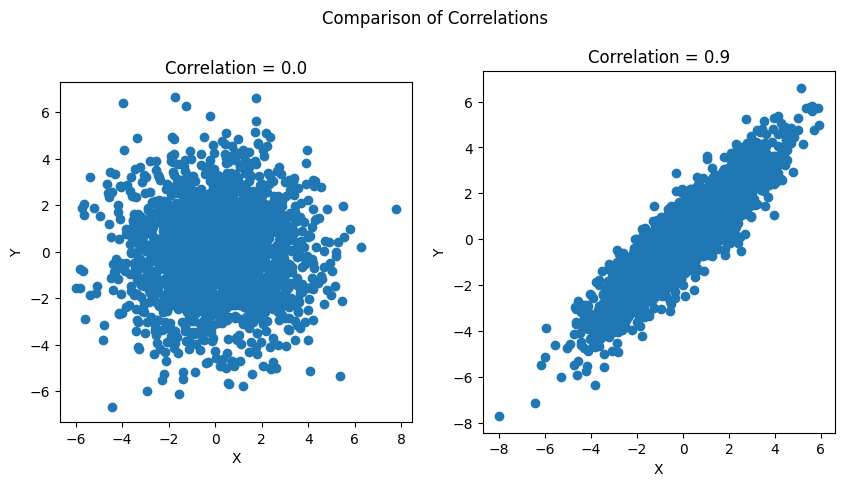

Task 9 passed.


In [23]:
_fig, _axes = compare_correlations(np.random.default_rng(3))

assert len(_axes) == 2, f"expected two Axes, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_aspect() == 1.0, f"panel {_i} does not have equal aspect"
    assert len(_ax.collections) > 0, f"panel {_i} has nothing plotted on it"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), \
    "the figure has no suptitle"

plt.show()
print("Task 9 passed.")

### Question 4 — the off-diagonal entry

Re-run `compare_correlations` mentally, or actually, with the right-hand
correlation set to **-0.9** instead of `0.9`.

Describe what changes in the picture and what does **not**. Specifically:
does the spread of `x` alone change? Does the spread of `y` alone change?
What would you see if you plotted a histogram of just the `x` coordinate
for correlation `0.0`, `0.9` and `-0.9` — could you tell the three cases
apart from that histogram?

Then state the consequence in one sentence: what does this say about
inspecting variables one at a time?

In [ ]:
# Space for the code that supports your answer.

**Your answer:**

Changing the right-hand correlation from 0.9 to -0.9 changes the direction of the cloud. With a correlation of 0.9, the points form an elongated cloud with an upward slope. With a correlation of -0.9, the points form an elongated cloud with a downward slope. With correlation 0.0, the cloud has no particular diagonal direction.

The spread of x alone does not change, and the spread of y alone does not change. The standard deviations of x and y remain the same; only their correlation changes.

If we plotted a histogram of only the x coordinate for correlations 0.0, 0.9, and -0.9, the histograms would look approximately the same. We could not distinguish the three cases from the x histogram alone because the marginal distribution of x is unchanged.

Therefore, inspecting variables one at a time can hide important relationships between them, so the relationships between variables should also be examined.


## 11. Task 10 — Histograms and the bin count

Applied. Draw one sample three ways and decide which picture to trust.

*see Practice 1 §4.5*

In [24]:
def histogram_grid(sample, bin_counts, density):
    """Plot sample as a histogram once per entry in bin_counts."""

    # One figure with len(bin_counts) panels in one row
    fig, axes = plt.subplots(
        1,
        len(bin_counts),
        figsize=(5 * len(bin_counts), 4)
    )

    # When there is only one panel, make axes iterable
    if len(bin_counts) == 1:
        axes = [axes]

    for ax, bins in zip(axes, bin_counts):
        ax.hist(sample, bins=bins, density=density)

        ax.set_xlabel("Value")

        if density:
            ax.set_ylabel("density")
        else:
            ax.set_ylabel("count")

        ax.set_title(f"Histogram with {bins} bins")

    fig.tight_layout()

    return fig, axes

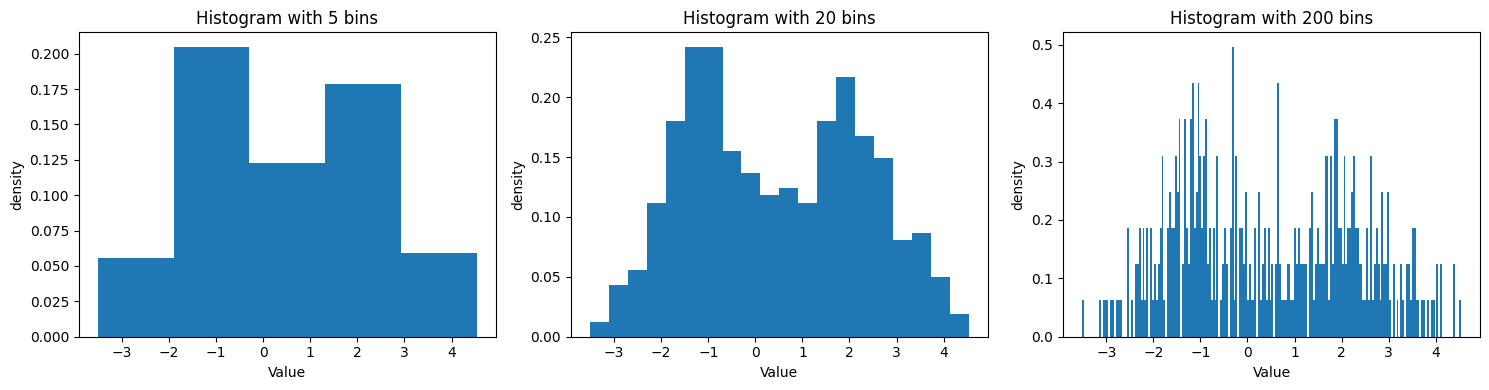

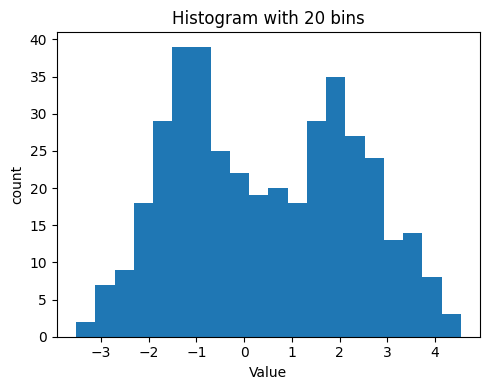

Task 10 passed.


In [25]:
# A deliberately awkward sample: two overlapping normals, 400 points.
_mixture = np.concatenate([
    np.random.default_rng(7).normal(-1.0, 1.0, 200),
    np.random.default_rng(8).normal(2.0, 1.0, 200),
])

_fig, _axes = histogram_grid(_mixture, [5, 20, 200], density=True)

assert len(_axes) == 3, f"expected three panels, got {len(_axes)}"
for _ax in _axes:
    assert _ax.get_xlabel(), "a panel has no x label"
    assert _ax.get_ylabel() == "density", \
        f"with density=True the y axis is a density, not a {_ax.get_ylabel()!r}"
    assert _ax.get_title(), "a panel has no title"
    assert len(_ax.patches) > 0, "a panel has no bars"

_fig_count, _axes_count = histogram_grid(_mixture, [20], density=False)
assert _axes_count[0].get_ylabel() == "count"

plt.show()
print("Task 10 passed.")

### Question 5 — bin count and density

Look at the three panels you just produced from `_mixture`, which was built
from **two** normal components centred at -1 and +2.

**(a)** At which bin count is the two-component structure visible? At which
is it hidden? At 200 bins, are the peaks you see real?

**(b)** Re-run `histogram_grid(_mixture, [5, 20, 200], density=False)` and
compare the y axes with the `density=True` version. The shapes are
identical but the numbers are not. Explain what `density=True` divides by,
and why that makes two samples **of different sizes** comparable on one
axis where raw counts would not be.

**(c)** A colleague shows you a histogram with a clear double peak and
concludes the population has two subgroups. What is the first question you
ask them?

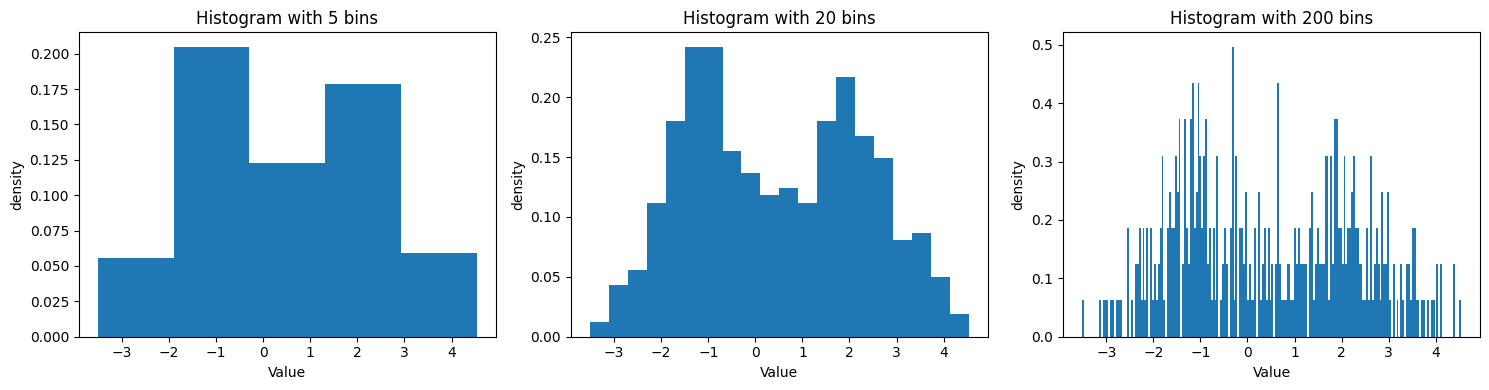

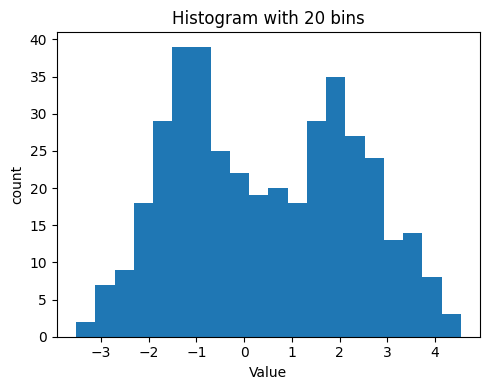

Task 10 passed.


In [26]:
_fig_density, _axes_density = histogram_grid(
    _mixture, [5, 20, 200], density=True
)

_fig_count, _axes_count = histogram_grid(
    _mixture, [5, 20, 200], density=False
)

plt.show()

**Your answer:**

_(replace this line)_

## 12. Task 11 — Open-ended

No assert. This one is marked on the written analysis.

You are given a sample of 5000 measurements below, produced by a generator
whose parameters you are not told. Your task is to **characterise it and
say what you would do with the extreme values**, using only the tools from
Practice 1.

Work through at least the following, and write up what you find:

1. Describe the array: shape, dtype, how much memory it occupies.
2. Compute the mean, the median, the standard deviation, the minimum and
   the maximum. The mean and the median differ noticeably. What does that
   tell you before you have plotted anything?
3. Plot it as a histogram. Choose the bin count deliberately and justify
   your choice in one sentence.
4. Apply the k-sigma rule from Task 5 at k = 3. How many points are
   flagged? Compare that count with the roughly 0.27 % you would expect
   from a normal sample of this size.
5. Now the judgement. Recompute the mean and standard deviation **with the
   flagged points removed**. Report both versions. Then argue, in a
   paragraph, whether the flagged points should be removed — and be
   explicit about what you would need to know about *how the data was
   measured* before you could answer that with any confidence.

A good answer treats step 5 as a question about the measurement process,
not about the numbers. A weak answer deletes the outliers because a rule
said so.

In [27]:
# The data. Do not modify this cell.
_hidden_rng = np.random.default_rng(31337)
mystery_sample = np.concatenate([
    _hidden_rng.normal(10.0, 2.0, 4_900),
    _hidden_rng.uniform(25.0, 60.0, 100),
])
_hidden_rng.shuffle(mystery_sample)

print("mystery_sample is ready:", mystery_sample.shape)

mystery_sample is ready: (5000,)


In [ ]:
# Your analysis. Add as many cells as you need.

**Your write-up:**
**(a)** Two-component structure is most clearly visible with **20 bins**. With only **5 bins**, the two peaks are hidden because the bins are too wide and combine the two components. With **200 bins**, the histogram becomes very noisy. The small peaks and fluctuations at 200 bins should not automatically be considered real features of the distribution; they can be caused by random sampling and overly narrow bins.

**(b)** With `density=True`, the histogram is normalized so that the total area of all bars is equal to 1. The heights therefore represent **probability density**, rather than the number of observations in each bin. This makes samples of different sizes comparable because their histogram areas are normalized to the same value. With `density=False`, the y-axis shows raw counts, so a larger sample will generally have larger bar heights simply because it contains more observations.

**(c)** The first question I would ask is: **How many bins were used, and does the double peak remain when the bin count or bin width is changed?** A double peak can be created or hidden by the choice of binning, so it should not immediately be interpreted as evidence of two subgroups.


## 13. Before you submit

- Runtime → **Restart and run all**. Every cell must execute in order with
  no error and every assert must pass.
- Every written question has an answer that refers to numbers you actually
  produced.
- Task 11 has a written conclusion, not only code.